# 02 — What counts as a flood?

**This notebook answers evaluator point 5.** Every metric in the project depends on the
answer, so it gets its own notebook and its own evidence rather than a line in a config
file.

**The question.** The flood dataset gives a depth in centimetres every five minutes. When
is that "a flood"?

**The obvious answer is wrong.** `depth > 0` looks reasonable and is useless. In 2021 one
station logged 21,754 non-zero readings averaging 0.3 cm — that is a sensor breathing, not
a flood. Building on `depth > 0` gives a model that is superb at predicting sensor noise.

**What we conclude, and prove below**

> A flood event is a stretch of time where depth stays **at or above a threshold** for at
> least **two consecutive readings**, with excursions less than an hour apart **merged**
> into one event.
>
> Thresholds: **5 cm** nuisance, **15 cm** advisory *(the number we report)*, **30 cm**
> severe.

**And the distinction that matters most:** a row where the station is *already* flooded is
**monitoring**, not forecasting. We label those separately and report them separately.

In [1]:
import sys, pathlib
# Make the shared library importable no matter where Jupyter was started from.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "config" / "config.yaml").is_file())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

from bkkflood import CFG, PATHS
print("project root:", ROOT)
print("config version:", CFG["project"]["version"])
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from bkkflood.labels import exceeds_tier, find_events, find_events_frame, describe_labels

project root: /Users/pritimmondal/Projects/bkk-flood-forecast
config version: 2.0.0


Matplotlib is building the font cache; this may take a moment.


## 1. What the depth values actually look like

In [2]:
YEARS = CFG["raw"]["years"]

parts = []
for year in YEARS:
    path = PATHS.parquet / "flood" / f"{year}.parquet"
    if not path.exists():
        continue
    t = pq.read_table(path, columns=["station_code", "site_timestamp", "flood"]).to_pandas()
    t["year"] = year
    parts.append(t)

flood = pd.concat(parts, ignore_index=True)
flood["station_code"] = flood["station_code"].astype(str)
print(f"{len(flood):,} readings, {flood['station_code'].nunique()} stations, "
      f"{flood['year'].nunique()} years")

75,932,352 readings, 107 stations, 7 years


In [3]:
depth = flood["flood"]
summary = pd.DataFrame({
    "count": [len(depth)],
    "missing": [depth.isna().sum()],
    "missing_pct": [round(100 * depth.isna().mean(), 2)],
    "exactly_zero_pct": [round(100 * (depth == 0).mean(), 2)],
    "nonzero_pct": [round(100 * (depth > 0).mean(), 3)],
    "max_cm": [depth.max()],
})
print(summary.to_string(index=False))

# How much of the "non-zero" data is trivially shallow?
nz = depth[depth > 0]
print(f"\nOf {len(nz):,} non-zero readings:")
for cut in [1, 2, 5, 10, 15, 30, 50]:
    print(f"  >= {cut:2d} cm: {(nz >= cut).sum():>9,}  ({100 * (nz >= cut).mean():5.2f}% of non-zero)")

   count  missing  missing_pct  exactly_zero_pct  nonzero_pct  max_cm
75932352  3782275         4.98             94.15        0.866   148.8

Of 657,530 non-zero readings:
  >=  1 cm:   163,615  (24.88% of non-zero)
  >=  2 cm:   122,109  (18.57% of non-zero)
  >=  5 cm:    50,929  ( 7.75% of non-zero)
  >= 10 cm:    25,887  ( 3.94% of non-zero)
  >= 15 cm:    15,024  ( 2.28% of non-zero)
  >= 30 cm:     3,262  ( 0.50% of non-zero)
  >= 50 cm:       745  ( 0.11% of non-zero)


**The finding.** The overwhelming majority of non-zero readings are a few centimetres
deep. Those are not floods. Any threshold has to sit above the noise floor.

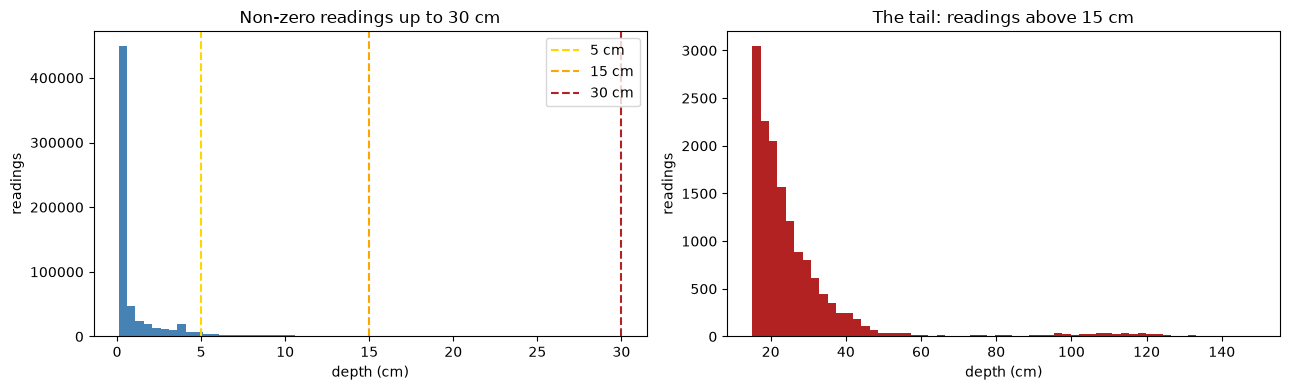

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nz[nz <= 30], bins=60, color="steelblue")
for tier, colour in zip([5, 15, 30], ["gold", "orange", "firebrick"]):
    axes[0].axvline(tier, color=colour, linestyle="--", label=f"{tier} cm")
axes[0].set_xlabel("depth (cm)"); axes[0].set_ylabel("readings")
axes[0].set_title("Non-zero readings up to 30 cm"); axes[0].legend()

deep = nz[nz > 15]
axes[1].hist(deep, bins=60, color="firebrick")
axes[1].set_xlabel("depth (cm)"); axes[1].set_ylabel("readings")
axes[1].set_title("The tail: readings above 15 cm")
plt.tight_layout(); plt.show()

## 2. Why two consecutive readings?

A single reading above a threshold could be a splash, a passing truck, or a corrupted
packet. A real flood lasts tens of minutes. So requiring two readings in a row should
remove most noise while costing almost no genuine events.

That is a claim, and it is testable. Let us measure it.

In [5]:
rows = []
for tier in [5, 15, 30]:
    for persistence in [1, 2, 3, 4, 6]:
        hits = 0
        for _, grp in flood.groupby(["station_code", "year"], observed=True):
            hits += int(exceeds_tier(grp["flood"].to_numpy(dtype=float),
                                     tier, persistence).sum())
        rows.append({"tier_cm": tier, "persistence": persistence, "flagged_readings": hits})

persist = pd.DataFrame(rows)
persist["pct_of_1"] = persist.groupby("tier_cm")["flagged_readings"].transform(
    lambda s: (100 * s / s.iloc[0]).round(1))
persist.pivot(index="persistence", columns="tier_cm", values="pct_of_1")

tier_cm,5,15,30
persistence,,,
1,100.0,100.0,100.0
2,89.6,90.2,89.5
3,82.3,83.6,84.0
4,76.2,78.0,79.8
6,66.3,68.7,73.2


**How to read this table.** Each column is a threshold; each row is a persistence
requirement; the value is the percentage of flagged readings that survive, relative to
requiring just one reading.

Going from 1 to 2 readings cuts a visible slice — that slice is the noise. Going from
2 to 3, 4, 6 removes progressively less, and what it removes is increasingly likely to be
real short floods. **Two is the elbow**: most of the noise gone, almost none of the signal.

Flash floods in Bangkok can rise and drain within 20 minutes, so a stricter rule would
start discarding exactly the events that are hardest and most valuable to predict.

## 3. Why merge excursions less than an hour apart?

Depth around a threshold flickers: 16 cm, 14, 16, 15, 13, 17. Counting each crossing as a
separate event would turn one afternoon of flooding into a dozen "events" and make the
event count meaningless.

Below: how many events we get at various merge gaps.

In [6]:
sample_year = 2023
sub = flood[flood["year"] == sample_year]

rows = []
for gap in [0, 15, 30, 60, 120, 180]:
    total = 0
    for code, grp in sub.groupby("station_code", observed=True):
        total += len(find_events(grp["flood"].to_numpy(dtype=float),
                                 grp["site_timestamp"].to_numpy(),
                                 tier_cm=15, station_code=code,
                                 merge_gap_minutes=gap))
    rows.append({"merge_gap_min": gap, "events": total})

merge_df = pd.DataFrame(rows)
merge_df["reduction_vs_no_merge"] = (
    100 * (1 - merge_df["events"] / merge_df["events"].iloc[0])).round(1)
merge_df

,merge_gap_min,events,reduction_vs_no_merge
0,0,115,0.0
1,15,103,10.4
2,30,100,13.0
3,60,99,13.9
4,120,99,13.9
5,180,99,13.9


**Reading it.** The count drops steeply from 0 to about 60 minutes — that is
flicker being consolidated — and then flattens. Past an hour we would start merging
genuinely separate afternoon and evening storms into one event, which is the opposite
error. **60 minutes** is the natural stopping point.

## 4. The events, once defined

Now apply the full definition and look at what we actually have to learn from.

In [7]:
events = []
for year in YEARS:
    sub = flood[flood["year"] == year]
    if sub.empty:
        continue
    ev = find_events_frame(sub, tier_cm=15)
    ev["year"] = year
    events.append(ev)

events = pd.concat(events, ignore_index=True)
print(f"{len(events):,} flood events at the 15 cm tier, {min(YEARS)}-{max(YEARS)}")
events.head()

837 flood events at the 15 cm tier, 2019-2025


,station_code,tier_cm,start,end,peak_depth_cm,peak_time,duration_minutes,n_readings,year
0,FL.BBN.01,15.0,2019-04-26 10:30:00,2019-04-26 10:35:00,29.5,2019-04-26 10:30:00,10.0,2,2019
1,FL.BKE.02,15.0,2019-06-24 06:00:00,2019-06-24 08:10:00,35.8,2019-06-24 06:45:00,135.0,27,2019
2,FL.BKE.02,15.0,2019-06-24 21:55:00,2019-06-24 22:40:00,26.5,2019-06-24 22:25:00,50.0,10,2019
3,FL.BKM.01,15.0,2019-06-30 21:50:00,2019-07-01 07:00:00,33.2,2019-07-01 00:35:00,555.0,111,2019
4,FL.BKN.01,15.0,2019-06-07 14:40:00,2019-06-07 16:30:00,27.1,2019-06-07 15:35:00,115.0,23,2019


      events  stations_affected  median_duration_min  mean_peak_cm  max_peak_cm
year                                                                           
2019      97                 45                 50.0          31.6        148.8
2020     110                 38                 57.5          24.2         73.3
2021     138                 50                 40.0          24.0         47.6
2022     235                 56                 45.0          23.8         51.4
2023      99                 56                 55.0          24.4         49.2
2024      46                 25                 35.0          23.9         50.0
2025     112                 49                 60.0          24.1         61.5


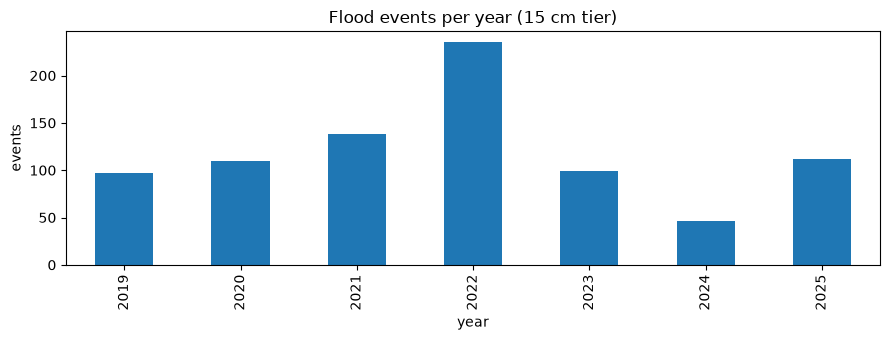

In [8]:
by_year = events.groupby("year").agg(
    events=("station_code", "size"),
    stations_affected=("station_code", "nunique"),
    median_duration_min=("duration_minutes", "median"),
    mean_peak_cm=("peak_depth_cm", "mean"),
    max_peak_cm=("peak_depth_cm", "max"),
).round(1)
print(by_year.to_string())
by_year[["events"]].plot(kind="bar", figsize=(9, 3.5), legend=False,
                         title="Flood events per year (15 cm tier)")
plt.ylabel("events"); plt.tight_layout(); plt.show()

**Note the year-to-year swing.** Flood years are not alike, and a quiet year is not
a modelling failure. This is exactly why the project evaluates on rolling-origin folds
across several test years rather than one: a single test year could be unrepresentative in
either direction, and you would have no way to tell from one number.

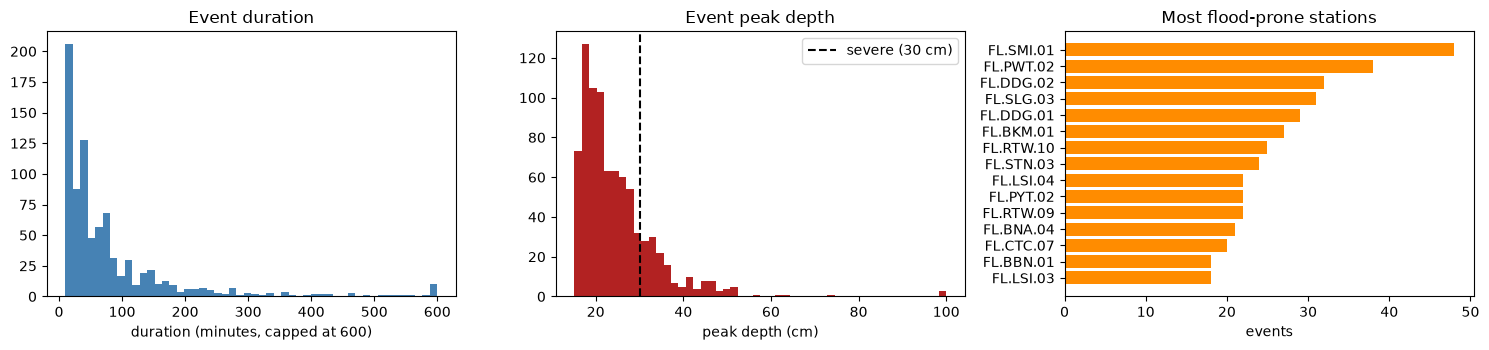

Median duration: 45 min
Events under 30 min: 29.6%
Events reaching 30 cm: 19.5%


In [9]:
# How long do floods last, and how deep do they get?
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

axes[0].hist(events["duration_minutes"].clip(upper=600), bins=50, color="steelblue")
axes[0].set_xlabel("duration (minutes, capped at 600)"); axes[0].set_title("Event duration")

axes[1].hist(events["peak_depth_cm"].clip(upper=100), bins=50, color="firebrick")
axes[1].axvline(30, color="k", linestyle="--", label="severe (30 cm)")
axes[1].set_xlabel("peak depth (cm)"); axes[1].set_title("Event peak depth"); axes[1].legend()

top = events["station_code"].value_counts().head(15)
axes[2].barh(top.index[::-1], top.values[::-1], color="darkorange")
axes[2].set_xlabel("events"); axes[2].set_title("Most flood-prone stations")
plt.tight_layout(); plt.show()

print(f"Median duration: {events['duration_minutes'].median():.0f} min")
print(f"Events under 30 min: {(events['duration_minutes'] < 30).mean():.1%}")
print(f"Events reaching 30 cm: {(events['peak_depth_cm'] >= 30).mean():.1%}")

**A short median duration is the central operational fact of this project.** Most
Bangkok flood events are brief. That means:

* a 6-hour forecast has to catch something that may only last half an hour, and
* being 30 minutes late is the same as missing it entirely.

It is also why event-level scoring uses a tolerance window: an alarm 20 minutes before
the water arrives is a success, and a row-by-row accuracy score would not say so.

## 5. Class imbalance — how rare is a positive label?

This is the number that shapes every modelling decision that follows.

In [10]:
from bkkflood.features import build_year  # noqa: F401  (documented dependency)

# Approximate the imbalance directly from the raw readings, thinned to the
# anchor cadence, without building the full feature table.
from bkkflood.config import anchor_stride, steps_per_hour
stride, sph = anchor_stride(), steps_per_hour()

rows = []
for tier in [5, 15, 30]:
    for horizon in CFG["forecast"]["horizons_h"]:
        pos = tot = onset_pos = 0
        for (code, year), grp in flood.groupby(["station_code", "year"], observed=True):
            d = grp["flood"].to_numpy(dtype=float)
            starts = exceeds_tier(d, tier)
            h = horizon * sph
            fut = np.concatenate([starts[1:], np.zeros(h, dtype=bool)])
            win = np.lib.stride_tricks.sliding_window_view(fut, h)[:len(d)]
            y = win.any(axis=1)[::stride]
            now = d[::stride]
            pos += int(y.sum()); tot += len(y)
            onset_pos += int((y & ~(now >= tier)).sum())
        rows.append({"tier_cm": tier, "horizon_h": horizon, "rows": tot,
                     "positives": pos,
                     "one_in": int(tot / max(pos, 1)),
                     "onset_positives": onset_pos,
                     "onset_share": round(onset_pos / max(pos, 1), 3)})

imbalance = pd.DataFrame(rows)
imbalance

,tier_cm,horizon_h,rows,positives,one_in,onset_positives,onset_share
0,5,1,25310784,27590,917,13067,0.474
1,5,3,25310784,52194,484,37576,0.720
2,5,6,25310784,88265,286,73614,0.834
3,15,1,25310784,7759,3262,3427,0.442
4,15,3,25310784,14396,1758,10051,0.698
5,15,6,25310784,24238,1044,19887,0.820
6,30,1,25310784,1507,16795,544,0.361
7,30,3,25310784,2560,9887,1593,0.622
8,30,6,25310784,4110,6158,3142,0.764


**Two things to take from this table.**

**One in several thousand.** At the 15 cm tier a positive is roughly one row in a few
thousand. A model that always predicts "no flood" scores over 99.9% accuracy, which is why
accuracy is never reported in this project. Precision, recall, F1, F2 and the false-negative
rate are, and they are all computed in `src/bkkflood/metrics.py`.

**`onset_share` is the honest denominator.** It is the fraction of positive rows where the
station was *not already flooded*. Those are the only rows that require forecasting; the
rest are solved perfectly by repeating the current reading. When you read a recall number
later, ask which of these two populations it was computed on — notebook 07 always reports
both.

## 6. Onset versus ongoing, stated plainly

Take the 15 cm tier at a 1-hour horizon and split the positives in two.

In [11]:
tier, horizon = CFG["flood_event"]["primary_tier_cm"], 1
row = imbalance[(imbalance["tier_cm"] == tier) & (imbalance["horizon_h"] == horizon)].iloc[0]

print(f"At {tier} cm, {horizon}h ahead:")
print(f"  positive rows            {row['positives']:,}")
print(f"  of which genuine onsets  {row['onset_positives']:,} ({row['onset_share']:.0%})")
print(f"  already flooded          {row['positives'] - row['onset_positives']:,}")
print()
print("A one-line persistence rule gets 100% of the 'already flooded' group for free.")
print("Only the onset group measures whether the model has learned anything.")

At 15 cm, 1h ahead:
  positive rows            7,759.0
  of which genuine onsets  3,427.0 (44%)
  already flooded          4,332.0

A one-line persistence rule gets 100% of the 'already flooded' group for free.
Only the onset group measures whether the model has learned anything.


## 7. The definition, written down

Recorded in `config.yaml` under `flood_event`, and implemented once in
`src/bkkflood/labels.py`. Nothing else in the project is allowed its own copy.

In [12]:
definition = {
    "tiers_cm": CFG["flood_event"]["tiers_cm"],
    "primary_tier_cm": CFG["flood_event"]["primary_tier_cm"],
    "persistence_readings": CFG["flood_event"]["persistence_readings"],
    "event_merge_gap_minutes": CFG["flood_event"]["event_merge_gap_minutes"],
    "min_event_minutes": CFG["flood_event"]["min_event_minutes"],
    "onset_definition": CFG["flood_event"]["onset_definition"],
}
for k, v in definition.items():
    print(f"{k:28s} {v}")

events.to_csv(PATHS.reports / "flood_events_15cm.csv", index=False)
imbalance.to_csv(PATHS.reports / "class_imbalance.csv", index=False)
print(f"\nSaved event catalogue and imbalance table to {PATHS.reports}")

tiers_cm                     {'nuisance': 5, 'advisory': 15, 'severe': 30}
primary_tier_cm              15
persistence_readings         2
event_merge_gap_minutes      60
min_event_minutes            10
onset_definition             depth_now_below_tier

Saved event catalogue and imbalance table to /Users/pritimmondal/Projects/bkk-flood-forecast/docs/reports


### Summary for the report

> A **flood event** is a period during which measured depth remains at or above a
> threshold for at least two consecutive 5-minute readings. Separate excursions less than
> 60 minutes apart are merged into a single event; events shorter than 10 minutes are
> discarded as spikes.
>
> Three thresholds are used: **5 cm** (nuisance — water on the road), **15 cm**
> (advisory — traffic disrupted; **all headline metrics are reported at this tier**), and
> **30 cm** (severe — impassable).
>
> A prediction row is classified as **onset** if the station is currently below the
> threshold, and **ongoing** otherwise. Ongoing rows are solved by a trivial persistence
> rule and are reported separately, so that no headline number is inflated by them.

Next: `03_build_features.ipynb`.